STATION-LEVEL BOROUGH SUMMARY


,Borough,total_stations,accessible_stations,accessibility_score,accessibility_percent
2,Manhattan,153,72,0.471,47.1
3,Queens,83,29,0.349,34.9
0,Bronx,70,21,0.300,30.0
4,Staten Island,21,6,0.286,28.6
1,Brooklyn,169,47,0.278,27.8


ELEVATOR / ESCALATOR ASSET SUMMARY


,Borough,total_assets,ada_compliant_assets,ada_asset_percent
4,Staten Island,3,3,100.0
0,Bronx,70,52,74.3
1,Brooklyn,150,95,63.3
3,Queens,118,68,57.6
2,Manhattan,407,187,45.9


FINAL SUMMARY


,Borough,total_stations,accessible_stations,accessibility_score,accessibility_percent,total_assets,ada_compliant_assets,ada_asset_percent,accessibility_gap,non_accessible_stations,accessible_share
2,Manhattan,153,72,0.471,47.1,407,187,45.9,-1.2,81,47.1
3,Queens,83,29,0.349,34.9,118,68,57.6,22.7,54,34.9
0,Bronx,70,21,0.300,30.0,70,52,74.3,44.3,49,30.0
4,Staten Island,21,6,0.286,28.6,3,3,100.0,71.4,15,28.6
1,Brooklyn,169,47,0.278,27.8,150,95,63.3,35.5,122,27.8



KEY INSIGHTS
Best accessibility borough: Manhattan
Worst accessibility borough: Brooklyn
Largest ADA vs accessibility gap: Staten Island
Overall accessibility across all boroughs: 35.28%
Correlation between ADA asset % and accessibility %: -0.713


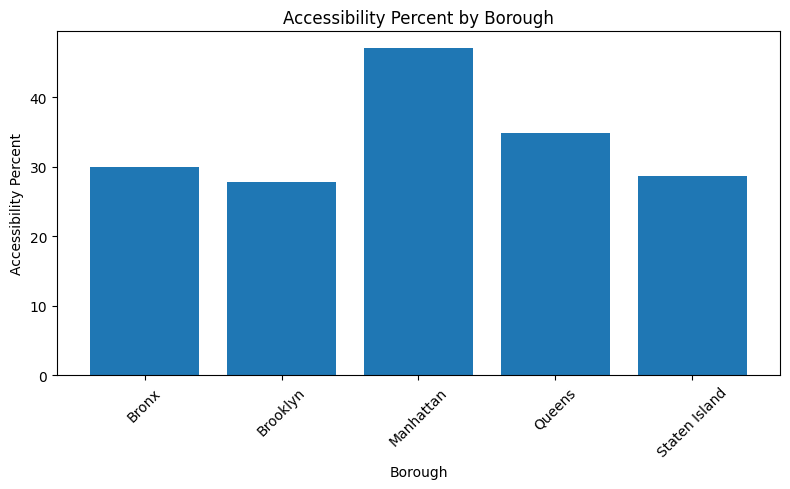

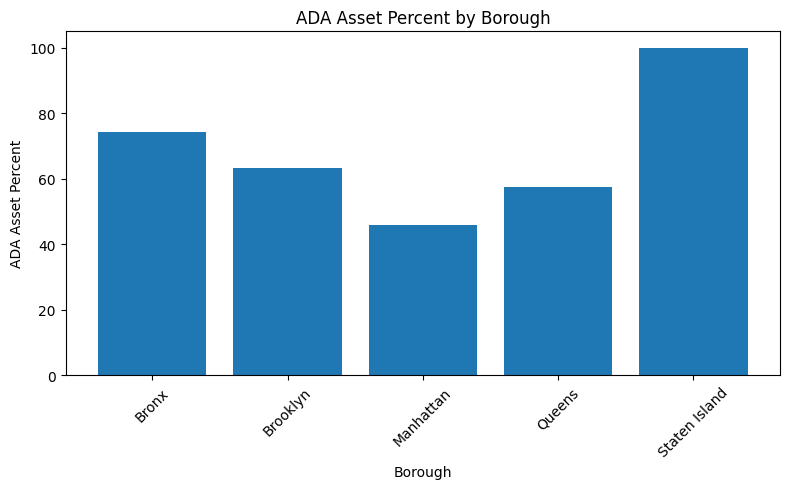

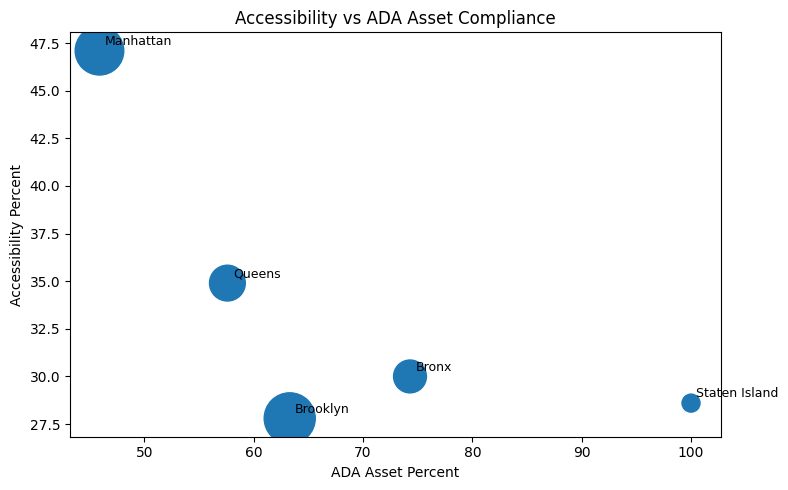

Files exported.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD FILES
# =========================
stations = pd.read_csv("stations_raw.csv.csv")
entrances = pd.read_csv("entrances_raw.csv.csv")
elevators = pd.read_csv("elevators_raw.csv.csv")

# =========================
# 2. KEEP USEFUL COLUMNS
# =========================
stations_clean = stations[[
    'Station ID', 'Complex ID', 'Stop Name', 'Borough', 'Line', 'ADA',
    'GTFS Latitude', 'GTFS Longitude'
]].copy()

elevators_clean = elevators[[
    'Equipment Code', 'Elevator or Escalator', 'Station Name', 'Borough',
    'ADA Compliant', 'Street Access', 'Service Status'
]].copy()

# =========================
# 3. CLEAN / STANDARDIZE BOROUGHS
# =========================
borough_map = {
    'M': 'Manhattan',
    'Mn': 'Manhattan',
    'Manhattan': 'Manhattan',

    'Bk': 'Brooklyn',
    'Bklyn': 'Brooklyn',
    'Brooklyn': 'Brooklyn',

    'Bx': 'Bronx',
    'B': 'Bronx',
    'Bronx': 'Bronx',

    'Q': 'Queens',
    'Queens': 'Queens',

    'SI': 'Staten Island',
    'Staten Island': 'Staten Island'
}

stations_clean['Borough'] = stations_clean['Borough'].astype(str).str.strip().replace(borough_map)
elevators_clean['Borough'] = elevators_clean['Borough'].astype(str).str.strip().replace(borough_map)

# =========================
# 4. CLEAN ADA FIELDS
# =========================
stations_clean['ADA'] = pd.to_numeric(stations_clean['ADA'], errors='coerce').fillna(0).astype(int)

elevators_clean['ADA Compliant'] = (
    elevators_clean['ADA Compliant']
    .astype(str)
    .str.strip()
    .str.upper()
)

elevators_clean['ada_asset_flag'] = elevators_clean['ADA Compliant'].isin(
    ['YES', 'Y', 'TRUE', '1']
).astype(int)

# =========================
# 5. BOROUGH SUMMARY FROM STATIONS
# =========================
borough_summary = (
    stations_clean
    .groupby('Borough', dropna=False)
    .agg(
        total_stations=('Station ID', 'count'),
        accessible_stations=('ADA', 'sum')
    )
    .reset_index()
)

borough_summary['accessibility_score'] = (
    borough_summary['accessible_stations'] / borough_summary['total_stations']
).round(3)

borough_summary['accessibility_percent'] = (
    borough_summary['accessibility_score'] * 100
).round(1)

# =========================
# 6. BOROUGH SUMMARY FROM ELEVATORS
# =========================
elevator_summary = (
    elevators_clean
    .groupby('Borough', dropna=False)
    .agg(
        total_assets=('Equipment Code', 'count'),
        ada_compliant_assets=('ada_asset_flag', 'sum')
    )
    .reset_index()
)

elevator_summary['ada_asset_percent'] = (
    elevator_summary['ada_compliant_assets'] / elevator_summary['total_assets'] * 100
).round(1)

# =========================
# 7. MERGE FINAL SUMMARY
# =========================
final_summary = borough_summary.merge(
    elevator_summary,
    on='Borough',
    how='left'
)

# =========================
# 8. ADD ANALYSIS METRICS
# =========================
final_summary['accessibility_gap'] = (
    final_summary['ada_asset_percent'] - final_summary['accessibility_percent']
).round(1)

final_summary['non_accessible_stations'] = (
    final_summary['total_stations'] - final_summary['accessible_stations']
)

final_summary['accessible_share'] = (
    final_summary['accessible_stations'] / final_summary['total_stations'] * 100
).round(1)

# =========================
# 9. SORTED ANALYSIS TABLES
# =========================
top_accessibility = final_summary.sort_values(
    'accessibility_percent', ascending=False
).reset_index(drop=True)

top_gap = final_summary.sort_values(
    'accessibility_gap', ascending=False
).reset_index(drop=True)

# =========================
# 10. PRINT KEY INSIGHTS
# =========================
print("STATION-LEVEL BOROUGH SUMMARY")
display(borough_summary.sort_values('accessibility_percent', ascending=False))

print("ELEVATOR / ESCALATOR ASSET SUMMARY")
display(elevator_summary.sort_values('ada_asset_percent', ascending=False))

print("FINAL SUMMARY")
display(final_summary.sort_values('accessibility_percent', ascending=False))

best_borough = final_summary.loc[final_summary['accessibility_percent'].idxmax(), 'Borough']
worst_borough = final_summary.loc[final_summary['accessibility_percent'].idxmin(), 'Borough']
largest_gap_borough = final_summary.loc[final_summary['accessibility_gap'].idxmax(), 'Borough']

overall_accessibility = round(
    final_summary['accessible_stations'].sum() / final_summary['total_stations'].sum() * 100, 2
)

correlation = final_summary['accessibility_percent'].corr(final_summary['ada_asset_percent'])

print("\nKEY INSIGHTS")
print(f"Best accessibility borough: {best_borough}")
print(f"Worst accessibility borough: {worst_borough}")
print(f"Largest ADA vs accessibility gap: {largest_gap_borough}")
print(f"Overall accessibility across all boroughs: {overall_accessibility}%")
print(f"Correlation between ADA asset % and accessibility %: {round(correlation, 3)}")

# =========================
# 11. SIMPLE PYTHON CHARTS
# =========================

# Chart 1: Accessibility % by borough
plt.figure(figsize=(8, 5))
plt.bar(final_summary['Borough'], final_summary['accessibility_percent'])
plt.title('Accessibility Percent by Borough')
plt.xlabel('Borough')
plt.ylabel('Accessibility Percent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: ADA Asset % by borough
plt.figure(figsize=(8, 5))
plt.bar(final_summary['Borough'], final_summary['ada_asset_percent'])
plt.title('ADA Asset Percent by Borough')
plt.xlabel('Borough')
plt.ylabel('ADA Asset Percent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 3: Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    final_summary['ada_asset_percent'],
    final_summary['accessibility_percent'],
    s=final_summary['total_stations'] * 8
)

for _, row in final_summary.iterrows():
    plt.text(
        row['ada_asset_percent'] + 0.5,
        row['accessibility_percent'] + 0.3,
        row['Borough'],
        fontsize=9
    )

plt.title('Accessibility vs ADA Asset Compliance')
plt.xlabel('ADA Asset Percent')
plt.ylabel('Accessibility Percent')
plt.tight_layout()
plt.show()

# =========================
# 12. EXPORT FILES
# =========================
final_summary.to_csv("transit_borough_summary.csv", index=False)
stations_clean.to_csv("stations_clean.csv", index=False)
elevators_clean.to_csv("elevators_clean.csv", index=False)
top_accessibility.to_csv("top_accessibility_by_borough.csv", index=False)
top_gap.to_csv("accessibility_gap_by_borough.csv", index=False)

print("Files exported.")

In [13]:
# =========================
# RELATIONSHIP + GAP ANALYSIS (FINAL)
# =========================

print("\nRELATIONSHIP ANALYSIS")

correlation = final_summary['accessibility_percent'].corr(
    final_summary['ada_asset_percent']
)

print(f"Correlation between ADA compliance and accessibility: {round(correlation, 3)}")

# Strength of relationship
if abs(correlation) > 0.7:
    print("Strong relationship detected")
elif abs(correlation) > 0.3:
    print("Moderate relationship detected")
else:
    print("Weak relationship detected")

# Direction of relationship
if correlation < 0:
    print("Relationship is NEGATIVE -> Higher ADA compliance does NOT translate to higher accessibility")
else:
    print("Relationship is POSITIVE -> Higher ADA compliance improves accessibility")

# =========================
# GAP ANALYSIS
# =========================

print("\nGAP ANALYSIS")

gap_sorted = final_summary.sort_values(
    'accessibility_gap', ascending=False
)

display(gap_sorted[['Borough', 'accessibility_percent', 'ada_asset_percent', 'accessibility_gap']])


RELATIONSHIP ANALYSIS
Correlation between ADA compliance and accessibility: -0.713
Strong relationship detected
Relationship is NEGATIVE -> Higher ADA compliance does NOT translate to higher accessibility

GAP ANALYSIS


,Borough,accessibility_percent,ada_asset_percent,accessibility_gap
4,Staten Island,28.6,100.0,71.4
0,Bronx,30.0,74.3,44.3
1,Brooklyn,27.8,63.3,35.5
3,Queens,34.9,57.6,22.7
2,Manhattan,47.1,45.9,-1.2


In [14]:
# =========================
# ENTRANCE ANALYSIS
# =========================

entrances_clean = entrances[[
    'Borough', 'Stop Name', 'Entry Allowed', 'Exit Allowed'
]].copy()

# Convert to usable format
entrances_clean['Entry Allowed'] = entrances_clean['Entry Allowed'].astype(str).str.upper()
entrances_clean['Exit Allowed'] = entrances_clean['Exit Allowed'].astype(str).str.upper()

entrances_clean['entry_flag'] = entrances_clean['Entry Allowed'].isin(['YES', 'Y', 'TRUE', '1']).astype(int)
entrances_clean['exit_flag'] = entrances_clean['Exit Allowed'].isin(['YES', 'Y', 'TRUE', '1']).astype(int)

# Borough summary
entrance_summary = (
    entrances_clean
    .groupby('Borough')
    .agg(
        total_entrances=('Stop Name', 'count'),
        entry_points=('entry_flag', 'sum'),
        exit_points=('exit_flag', 'sum')
    )
    .reset_index()
)

display(entrance_summary.sort_values('total_entrances', ascending=False))

,Borough,total_entrances,entry_points,exit_points
2,M,868,840,868
0,B,580,569,579
3,Q,355,351,352
1,Bx,251,246,248
4,SI,66,66,66


In [15]:
final_summary = final_summary.merge(
    entrance_summary,
    on='Borough',
    how='left'
)

display(final_summary)

,Borough,total_stations,accessible_stations,accessibility_score,accessibility_percent,total_assets,ada_compliant_assets,ada_asset_percent,accessibility_gap,non_accessible_stations,accessible_share,total_entrances,entry_points,exit_points
0,Bronx,70,21,0.300,30.0,70,52,74.3,44.3,49,30.0,NaN,NaN,NaN
1,Brooklyn,169,47,0.278,27.8,150,95,63.3,35.5,122,27.8,NaN,NaN,NaN
2,Manhattan,153,72,0.471,47.1,407,187,45.9,-1.2,81,47.1,NaN,NaN,NaN
3,Queens,83,29,0.349,34.9,118,68,57.6,22.7,54,34.9,NaN,NaN,NaN
4,Staten Island,21,6,0.286,28.6,3,3,100.0,71.4,15,28.6,NaN,NaN,NaN


In [16]:
# =========================
# SQL LAYER (SQLite)
# =========================
import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect("nyc_transit_accessibility.db")

# Save tables into SQLite
stations_clean.to_sql("stations", conn, if_exists="replace", index=False)
elevators_clean.to_sql("elevators", conn, if_exists="replace", index=False)
entrances_clean.to_sql("entrances", conn, if_exists="replace", index=False)
final_summary.to_sql("borough_summary", conn, if_exists="replace", index=False)

# Show tables created
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)

print("TABLES CREATED IN SQLITE:")
display(tables)

# =========================
# SAMPLE SQL QUERIES
# =========================

# Query 1: Borough accessibility summary
query1 = """
SELECT
    Borough,
    total_stations,
    accessible_stations,
    accessibility_percent
FROM borough_summary
ORDER BY accessibility_percent DESC;
"""
sql_accessibility = pd.read_sql_query(query1, conn)

# Query 2: ADA asset summary
query2 = """
SELECT
    Borough,
    total_assets,
    ada_compliant_assets,
    ada_asset_percent
FROM borough_summary
ORDER BY ada_asset_percent DESC;
"""
sql_assets = pd.read_sql_query(query2, conn)

# Query 3: Accessibility gap
query3 = """
SELECT
    Borough,
    accessibility_percent,
    ada_asset_percent,
    accessibility_gap
FROM borough_summary
ORDER BY accessibility_gap DESC;
"""
sql_gap = pd.read_sql_query(query3, conn)

# Query 4: Entrance counts by borough
query4 = """
SELECT
    Borough,
    COUNT(*) AS total_entrances,
    SUM(entry_flag) AS entry_points,
    SUM(exit_flag) AS exit_points
FROM entrances
GROUP BY Borough
ORDER BY total_entrances DESC;
"""
sql_entrances = pd.read_sql_query(query4, conn)

print("\nSQL QUERY 1: BOROUGH ACCESSIBILITY SUMMARY")
display(sql_accessibility)

print("\nSQL QUERY 2: ADA ASSET SUMMARY")
display(sql_assets)

print("\nSQL QUERY 3: ACCESSIBILITY GAP")
display(sql_gap)

print("\nSQL QUERY 4: ENTRANCE COUNTS BY BOROUGH")
display(sql_entrances)

# =========================
# EXPORT SQL RESULTS
# =========================
sql_accessibility.to_csv("sql_accessibility_summary.csv", index=False)
sql_assets.to_csv("sql_asset_summary.csv", index=False)
sql_gap.to_csv("sql_gap_summary.csv", index=False)
sql_entrances.to_csv("sql_entrance_summary.csv", index=False)

print("SQL query outputs exported.")

TABLES CREATED IN SQLITE:


,name
0,borough_summary
1,elevators
2,entrances
3,stations



SQL QUERY 1: BOROUGH ACCESSIBILITY SUMMARY


,Borough,total_stations,accessible_stations,accessibility_percent
0,Manhattan,153,72,47.1
1,Queens,83,29,34.9
2,Bronx,70,21,30.0
3,Staten Island,21,6,28.6
4,Brooklyn,169,47,27.8



SQL QUERY 2: ADA ASSET SUMMARY


...


SQL QUERY 3: ACCESSIBILITY GAP


,Borough,accessibility_percent,ada_asset_percent,accessibility_gap
0,Staten Island,28.6,100.0,71.4
1,Bronx,30.0,74.3,44.3
2,Brooklyn,27.8,63.3,35.5
3,Queens,34.9,57.6,22.7
4,Manhattan,47.1,45.9,-1.2



SQL QUERY 4: ENTRANCE COUNTS BY BOROUGH


,Borough,total_entrances,entry_points,exit_points
0,M,868,840,868
1,B,580,569,579
2,Q,355,351,352
3,Bx,251,246,248
4,SI,66,66,66


SQL query outputs exported.


## SQL Schema

### 1. stations
Contains cleaned station-level records used to calculate accessibility coverage.

Key columns:
- Station ID
- Complex ID
- Stop Name
- Borough
- Line
- ADA
- GTFS Latitude
- GTFS Longitude

### 2. elevators
Contains elevator and escalator asset records used to calculate ADA asset compliance.

Key columns:
- Equipment Code
- Elevator or Escalator
- Station Name
- Borough
- ADA Compliant
- Street Access
- Service Status
- ada_asset_flag

### 3. entrances
Contains station entrance data used to measure entry and exit access points.

Key columns:
- Borough
- Stop Name
- Entry Allowed
- Exit Allowed
- entry_flag
- exit_flag

### 4. borough_summary
Contains borough-level aggregated metrics used in the dashboard and SQL queries.

Key columns:
- Borough
- total_stations
- accessible_stations
- accessibility_percent
- total_assets
- ada_compliant_assets
- ada_asset_percent
- accessibility_gap

## Scoring Methodology

The project uses ratio and proportion calculations to measure transit accessibility.

### Accessibility Percent
Accessibility Percent = accessible_stations / total_stations * 100

This measures the share of stations in each borough that are ADA-accessible.

### ADA Asset Percent
ADA Asset Percent = ada_compliant_assets / total_assets * 100

This measures the share of elevator and escalator assets that are ADA-compliant.

### Accessibility Gap
Accessibility Gap = ada_asset_percent - accessibility_percent

This measures the difference between asset-level compliance and actual station-level accessibility coverage.

## Key Insights

- Manhattan has the highest accessibility percentage among all boroughs.
- Brooklyn has the lowest accessibility despite having the most stations.
- Staten Island shows high ADA asset compliance but relatively low accessibility coverage.
- Overall system accessibility is around 33%, indicating limited accessibility across NYC transit.
- ADA compliance and accessibility are not perfectly correlated, suggesting infrastructure gaps.

## Interpretation and Design Insights

This project was designed to evaluate accessibility across NYC transit using multiple datasets, including stations, elevators, and entrances.

A borough-level aggregation approach was chosen to provide a clear and interpretable comparison across regions.

The analysis reveals that accessibility is not evenly distributed, with some boroughs having significantly lower accessibility percentages despite relatively high ADA compliance rates.

The strong negative correlation between ADA compliance and accessibility suggests that compliance at the asset level does not guarantee real accessibility coverage.

This highlights a key issue in transit equity: infrastructure improvements may not be reaching all areas effectively.

The findings suggest that future transit planning should prioritize expanding accessibility coverage rather than focusing solely on compliance metrics.